# DAP Initial EDA Template

Disclaimer: 
- If your plan is to scrape data, you are to acquire minimally 500 rows of data (the more the better), and populate this template with your current available data.
- If you're working with non-tabular data like images and audio, you are to engineer your own features and populate this template. Focus more on structure and meta-data analysis, then perform image specifc (pixel intensity, colour analysis, etc) or audio specific (signal-to-noise, zero-crossing rate) data quality metrics instead of just "missing or mismatching rows"
- If you are working with Reinforcement learning, don't use this template at all, consult Supa-att for what you need to show for your specific RL agent.

### Setup

In [2]:
import ast
import csv
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

DATA = Path("../data/raw")

# One accent colour for single-series charts, a muted grey for context, a single-hue ramp for magnitude.
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#b5b3ad"
INK, MUTED = "#0b0b0b", "#898781"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "font.size": 9, "legend.frameon": False,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

## Dataset for Prompt Encoding: EmpatheticDialogues

### 1. Summarise the background of the dataset(s) which you're using, and how they contribute to your project [limited to 100 words per dataset]

**Response.**

EmpatheticDialogues has 24,850 conversations written by crowdworkers. Each writer picked one of 32 emotions, described a situation from their own life where they felt it, then talked about it with another worker. 

The situation text (*"My dog died and I was just heartbroken"*) is short, first-person and about a life event, which makes it the relevant to what our users might type (*"I'm going through a breakup"*). We will use this to train and test the Prompt Encoder.

#### Loading the raw files

The authors split the dataset into three CSVs. We combine all three for ease of analysis.

Each row is an **utterance** which is a turn in one conversation, so each conversation spans 1–8 rows. 

Our unit of analysis is the **situation**. Our "situation" comes from the 'prompt' the speaker wrote. Situation is one per conversation. Therefore, one row -> one conversation.

In [9]:
ED_COLS = ["conv_id", "utterance_idx", "context", "prompt", "speaker_idx", "utterance", "selfeval", "tags"]
ED_SPLITS = ["train", "valid", "test"]


def read_ed(split):
    return pd.read_csv(DATA / "empatheticdialogues" / f"{split}.csv", names=ED_COLS, header=0,
                       usecols=range(8), quoting=csv.QUOTE_NONE, dtype=str, keep_default_na=False
                       ).assign(split=split)


utt = pd.concat([read_ed(s) for s in ED_SPLITS], ignore_index=True)
utt["utterance_idx"] = utt["utterance_idx"].astype(int)
for col in ["prompt", "utterance"]:
    utt[col] = utt[col].str.replace("_comma_", ",", regex=False)

# One row per conversation (= one situation): its first utterance.
ed = (utt.loc[utt.groupby("conv_id")["utterance_idx"].idxmin()] # get first utterance
         .sort_index()
         .rename(columns={"context": "emotion", "prompt": "situation", "utterance": "first_utterance"})
         [["split", "conv_id", "emotion", "situation", "first_utterance"]]
         .reset_index(drop=True))
ed["n_words"] = ed["situation"].str.split().str.len()

# # Our grouping of the 32 labels for the mood dimensions (Stage 1); "unclear" still needs a team decision.
# MUSIC_MOODS = {"sad", "devastated", "lonely", "nostalgic", "sentimental", "hopeful", "anxious",
#                "joyful", "content", "excited", "afraid"}
# NOT_MUSIC = {"guilty", "ashamed", "jealous", "embarrassed", "disgusted", "impressed", "prepared",
#              "faithful", "trusting"}
# ed["label_group"] = np.select([ed["emotion"].isin(MUSIC_MOODS), ed["emotion"].isin(NOT_MUSIC)],
#                               ["music mood", "not a music mood"], "unclear")

ed.head()

,split,conv_id,emotion,situation,first_utterance,n_words
0,train,hit:0_conv:1,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. ...,25
1,train,hit:1_conv:2,afraid,i used to scare for darkness,it feels like hitting to blank wall when i see the darkness,6
2,train,hit:1_conv:3,proud,I showed a guy how to run a good bead in welding class and he caught on quick.,Hi how are you doing today,18
3,train,hit:2_conv:4,faithful,I have always been loyal to my wife.,I have never cheated on my wife.,8
4,train,hit:2_conv:5,terrified,A recent job interview that I had made me feel very anxious because I felt like I didn't come prepared.,"Job interviews always make me sweat bullets, makes me uncomfortable in general to be looked at under a microscope li...",20


### 2. State the size of your dataset(s)

In [6]:
ed_dir = DATA / "empatheticdialogues"
size = pd.DataFrame({
    "file MB": {s: round((ed_dir / f"{s}.csv").stat().st_size / 1e6, 1) for s in ED_SPLITS},
    "utterances": utt["split"].value_counts(),
    "situations": ed["split"].value_counts(),
}).loc[ED_SPLITS]
size.loc["total"] = size.sum()
display(size)
print(f"utterance table: {utt.shape[0]:,} rows x {len(ED_COLS)} columns")
print(f"situation table: {ed.shape[0]:,} rows; {ed['situation'].nunique():,} unique situation texts")
print(f"emotion labels: {ed['emotion'].nunique()}; crowdworker IDs: {utt['speaker_idx'].nunique()}")
print(f"utterances per conversation: {utt.groupby('conv_id').size().describe()[['min', '50%', 'max']].to_dict()}")

,file MB,utterances,situations
train,17.4,84169.0,19533.0
valid,38.9,12078.0,2770.0
test,36.6,10973.0,2547.0
total,92.9,107220.0,24850.0


utterance table: 107,220 rows x 8 columns
situation table: 24,850 rows; 24,503 unique situation texts
emotion labels: 32; crowdworker IDs: 810
utterances per conversation: {'min': 1.0, '50%': 4.0, 'max': 8.0}


**Response.**

- **Raw files:** 107,220 utterances × 8 columns
- **Situation table (what we analyse and train on):** **24,850 rows**, one per conversation. 24,503 of the situation texts are unique.
- **32 emotion labels**, 810 crowdworker IDs, 1–8 utterances per conversation (median 4).

### 3. For each feature of your dataset, describe what it represents and its data type (numerical, categorical, unstructured string, etc)

**Response.**

| Feature | Table | What it represents | Data type |
|---|---|---|---|
| `conv_id` | both | ID of the conversation, e.g. `hit:0_conv:1` | categorical (ID) |
| `utterance_idx` | raw | turn number inside the conversation (1–8) | numerical, ordinal integer |
| `context` → **`emotion`** | both | the emotion the writer picked before writing. **Our label** | categorical, 32 levels |
| `prompt` → **`situation`** | both | the writer's description of a time they felt that emotion. **Our model input** | unstructured string |
| `speaker_idx` | raw | anonymised ID of the crowdworker who wrote the utterance | categorical (ID), 810 levels |
| `utterance` | raw | one turn of the dialogue | unstructured string |
| `selfeval` | raw | the two workers' 1–5 ratings of the conversation after it ended, e.g. `5\|5\|5_2\|2\|5` (three ratings per worker, workers separated by `_`) | string encoding 6 ordinal ratings |
| `tags` | raw | flags on a few utterances: `<UNIGRAM>`, `<HI>`, `<POLITICAL>`, `<NUMERAL>` | categorical (space-separated flags) |
| `split` | both (added) | which file the row came from: train / valid / test | categorical, 3 levels |
| `first_utterance` | derived | the first turn of the dialogue, usually the writer retelling the situation | unstructured string |
| `n_words` | derived | number of words in `situation` | numerical, integer |

In [14]:
display(utt.dtypes.rename("raw dtype").to_frame().T)
utt.head(3)

,conv_id,utterance_idx,context,prompt,speaker_idx,utterance,selfeval,tags,split
raw dtype,str,int64,str,str,str,str,str,str,str


,conv_id,utterance_idx,context,prompt,speaker_idx,utterance,selfeval,tags,split
0,hit:0_conv:1,1,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",1,I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. ...,5|5|5_2|2|5,,train
1,hit:0_conv:1,2,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",0,"Was this a friend you were in love with, or just a best friend?",5|5|5_2|2|5,,train
2,hit:0_conv:1,3,sentimental,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the wo...",1,This was a best friend. I miss her.,5|5|5_2|2|5,,train


### 4. For each feature, determine percentage of missing data. Describe how you're planning on resolving the missing data. State any assumptions you make

In [11]:
def pct_missing(df):
    """NaN or blank text counts as missing."""
    blank = df.apply(lambda c: c.isna() | c.astype(str).str.strip().eq(""))
    return (blank.mean() * 100).round(2)

display(pd.concat({"utterance table": pct_missing(utt[ED_COLS]),
                   "situation table": pct_missing(ed)}, axis=1))

short = ed[ed["n_words"] <= 3]
print(f"situations with <= 3 words: {len(short)} ({len(short) / len(ed):.2%})")
print("situations with no letters at all (e.g. '1'):", (~ed["situation"].str.contains("[A-Za-z]")).sum())
short[["emotion", "situation"]].head(12)

,utterance table,situation table
conv_id,0.00,0.0
utterance_idx,0.00,NaN
context,0.00,NaN
prompt,0.00,NaN
speaker_idx,0.00,NaN
utterance,0.00,NaN
selfeval,0.00,NaN
tags,99.15,NaN
split,NaN,0.0
emotion,NaN,0.0


situations with <= 3 words: 146 (0.59%)
situations with no letters at all (e.g. '1'): 21


,emotion,situation
147,anticipating,waiting for christmas!
222,angry,Lies
498,sad,1
663,devastated,I am devasted.
801,proud,2
958,disappointed,1
1403,prepared,ready to move
1585,proud,Graduating High School!
1771,sad,I ma devastated.
2080,sentimental,1


**Response.**

- **There are no NaNs in the raw table.** The only column with real gaps is `tags` (99.15% empty), because it is only set on a few flagged utterances. We don't use it, so nothing needs resolving.
- **Every situation has text, but some are effectively missing.** 146 situations (0.59%) have ≤ 3 words. Most are still meaningful (*"Failing Algebra"*, *"My marriage"*, *"Lies"*), but **21 contain no letters at all** (`1`, `2`) and carry no information.
- **Plan:** drop the 21 situations with no letters and keep the other short ones, since real users also type short prompts.
- **Assumption:** the label of a placeholder situation can't be checked against its text, so dropping these loses nothing.

### 5. For each feature, identify outliers or mismatched data. Describe how you plan to handle them. Clearly state any assumption you made.

In [24]:
# 1) The same situation text more than once
dup = ed[ed.duplicated("situation", keep=False)]
per_text = dup.groupby("situation").agg(n=("emotion", "size"), labels=("emotion", "nunique"),
                                        splits=("split", "nunique"))
print(f"rows with a repeated situation: {len(dup)} ({per_text.shape[0]} distinct texts)")
print(f"  texts with conflicting labels: {(per_text['labels'] > 1).sum()}")
print(f"  texts appearing in more than one split (train/test leakage): {(per_text['splits'] > 1).sum()}")
display(dup[dup["situation"].isin(per_text.index[per_text["labels"] > 1])]
        .sort_values("situation")[["situation", "emotion", "split"]].head(8))

# 2) Length outliers (1.5 x IQR rule)
q1, q3 = ed["n_words"].quantile([.25, .75])
upper = q3 + 1.5 * (q3 - q1)
print(f"length IQR fence: > {upper:.0f} words -> {(ed['n_words'] > upper).sum()} situations "
      f"({(ed['n_words'] > upper).mean():.1%}); longest = {ed['n_words'].max()} words")

# 3) Text-level oddities
print("non-ASCII situations:", ed["situation"].str.contains(r"[^\x00-\x7F]").sum())
print("leading/trailing whitespace:", (ed["situation"] != ed["situation"].str.strip()).sum())
print("all-lowercase start:", ed["situation"].str.strip().str.match(r"[a-z]").sum())

# 4) Label vs text mismatches: one event under many labels, and a label the text doesn't show
ed.loc[ed["situation"].str.contains("bought a new car|brother was working in my office", case=False),
       ["emotion", "situation"]]

rows with a repeated situation: 534 (187 distinct texts)
  texts with conflicting labels: 78
  texts appearing in more than one split (train/test leakage): 4


,situation,emotion,split
10948,"I hate scary movies, they scare me so much, especially jumpscares",terrified,train
10940,"I hate scary movies, they scare me so much, especially jumpscares",afraid,train
10937,"I hate scary movies, they scare me so much, especially jumpscares",terrified,train
10923,"I hate scary movies, they scare me so much, especially jumpscares",terrified,train
5642,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",terrified,train
4050,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",angry,train
3752,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",afraid,train
3721,"I used to be afraid of the dark but now I am not so much, I had a nightlight for a long time",afraid,train


length IQR fence: > 41 words -> 838 situations (3.4%); longest = 136 words
non-ASCII situations: 5
leading/trailing whitespace: 2055
all-lowercase start: 2376


,emotion,situation
1281,excited,I bought a new car a few days ago. It's really sleek and fun to drive
3664,impressed,My friend just bought a new car and I can't believe how cheap he got it for.
4402,sentimental,My brother was working in my office
6312,jealous,My friend bought a new car.
7826,impressed,Just bought a new car and I'm surprised at how well it drives.
8700,grateful,I just bought a new car because of my new job and I am very happy
14700,jealous,My best friend just bought a new car. It's hard not to be a bit envious when my car is a 2006
16299,jealous,My neighbours just bought a new car and put in a pool. I feel like I just can't get ahead- I can barely pay the bills.
20617,jealous,My neighbor bought a new car. Now I really want one myself.
20702,jealous,A friend of mine bought a new car. It was a model I had my eye on for some time


**Response.**

**1. Duplicate situations.** 534 rows share their situation text with at least one other row (187 distinct texts). Usually the same writer reused one situation for several conversations.
- **78 of those texts have conflicting labels.** For example, *"I used to be afraid of the dark…"* is labelled afraid, terrified and angry.
- **4 texts appear in more than one split**, so the same text would be in both training and test data.
- *Plan:* keep one row per text with its majority label, and drop texts whose labels tie. Put all copies of a text in the same split.

**2. Length outliers.** The 1.5 × IQR fence is 41 words. 838 situations (3.4%) are above it; the longest has 136 words.
- *Plan:* keep them. They are genuine long descriptions, and 136 words is well below the 256-token limit of the sentence-transformer encoder.

**3. Formatting.**
- 2,055 situations have leading or trailing whitespace, and 2,376 start in lower case.
- 5 contain non-ASCII characters, and there are typos (*"I am devasted"*, *"I ma devastated"*).
- *Plan:* strip whitespace. Keep case and typos.
- *Assumption:* users type like this too, and the pretrained encoder copes with it.

**4. Labels that don't match the text.** The writer chose the label and nobody checked it.
- The same event gets very different labels depending on the writer's point of view. *"…bought a new car"* is labelled excited, grateful, jealous and impressed.
- Some pairs look like noise (*"My brother was working in my office"* → sentimental).
- *Plan:* the data can't fix this. Treat each label as "this dimension is high", not "the others are zero". Report results per dimension, and optionally add Jev scores across all dimensions.

**5. Labels that aren't music moods.** 9 labels (guilty, ashamed, jealous, embarrassed, disgusted, impressed, prepared, faithful, trusting) cover 6,372 situations (26%). They get mapped or dropped when we fix the dimensions (Stage 1).

### 6. For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

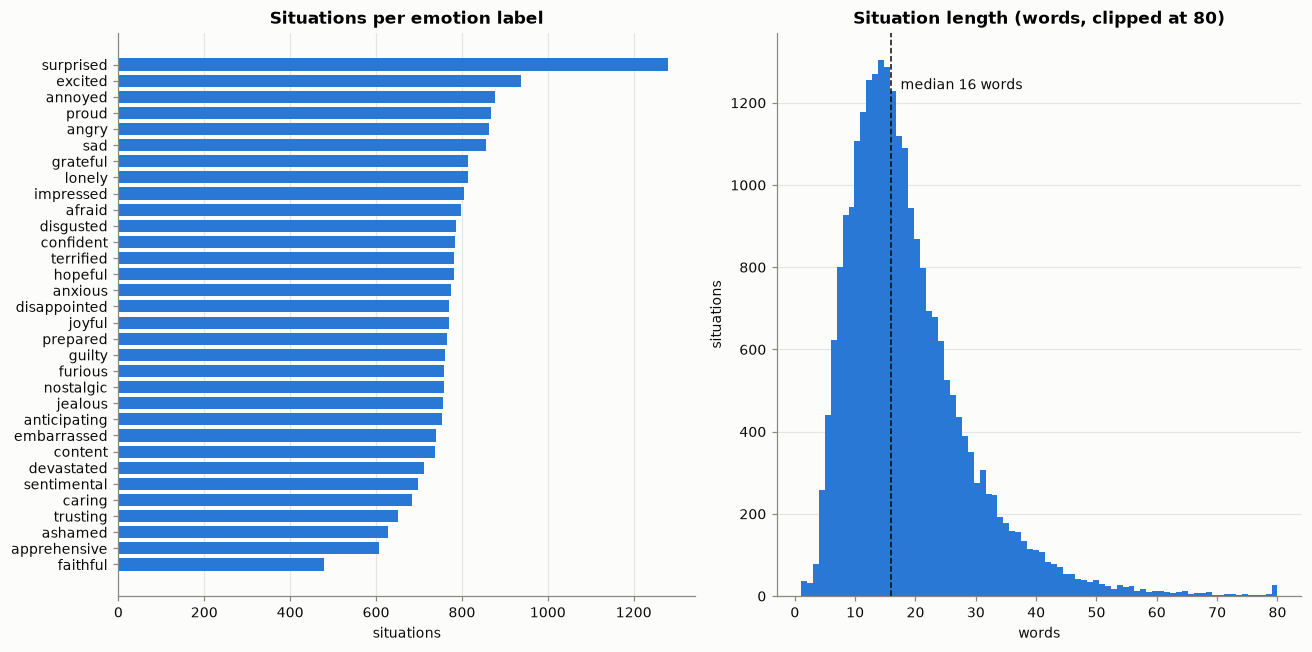

label counts: min 478 (faithful), max 1279 (surprised), median 770
start in the first person: 76%
mention music/songs: 116


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1.1, 1]})

counts = ed["emotion"].value_counts().sort_values()
axes[0].barh(counts.index, counts.values, color=BLUE, height=0.75)
axes[0].set_title("Situations per emotion label")
axes[0].set_xlabel("situations")
axes[0].grid(axis="y", visible=False)

axes[1].hist(ed["n_words"].clip(upper=80), bins=80, color=BLUE)
med = ed["n_words"].median()
axes[1].axvline(med, color=INK, lw=1, ls="--")
axes[1].annotate(f"median {med:.0f} words", (med, axes[1].get_ylim()[1] * .9), xytext=(6, 0),
                 textcoords="offset points", color=INK)
axes[1].set_title("Situation length (words, clipped at 80)")
axes[1].set_xlabel("words")
axes[1].set_ylabel("situations")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

first_person = ed["situation"].str.match(r"(?i)^\s*(?:i|i'm|i've|i'd|i'll|my|me|we|we're|our|us)\b")
print(f"label counts: min {counts.min()} ({counts.idxmin()}), max {counts.max()} ({counts.idxmax()}), "
      f"median {counts.median():.0f}")
print(f"start in the first person: {first_person.mean():.0%}")
music_mentions = ed["situation"].str.contains(r"(?i)\b(?:music|songs?)\b").sum()
print(f"mention music/songs: {music_mentions}")

**Response.**

**Emotion label.**
- The labels are fairly balanced, from 478 (*faithful*) to 1,279 (*surprised*), median 770. Only *surprised* stands out, at about 1.7× the median, so no resampling is needed.

**Situation length.**
- Lengths are right-skewed: median **16 words**, 80% between 8 and 32 words.
- **76% start in the first person** ("I", "my", "we"…), which matches how a user would describe their mood.

**Content.** Only 116 situations mention music or songs. They describe life events, not music requests. That is fine for learning what a prompt means, but it means our own hand-written prompts are needed as the real test.

**Split** (Q2): 79 / 11 / 10%.

### 7. Perform bi-variate analysis on some of the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables.

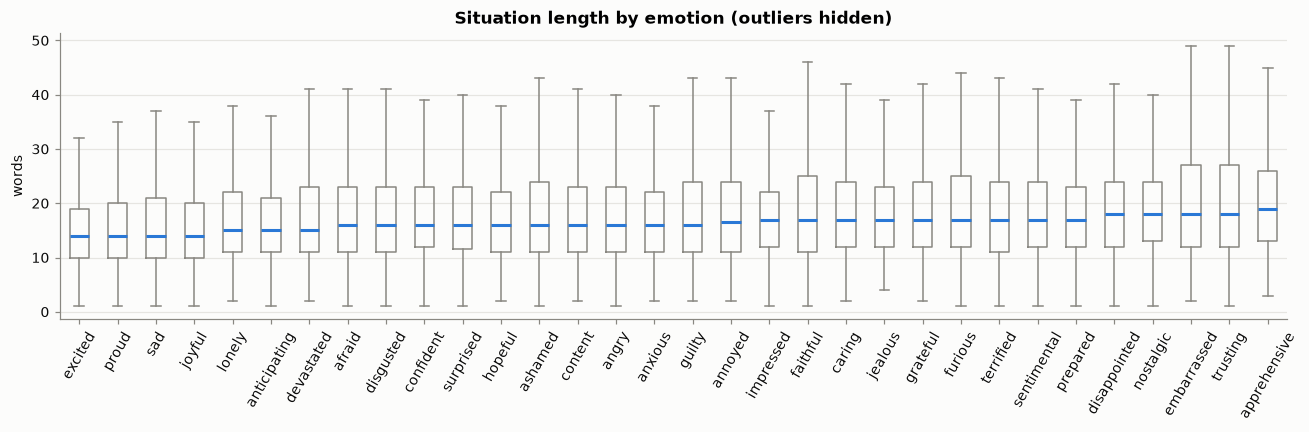

In [26]:
# Emotion x situation length
order = ed.groupby("emotion")["n_words"].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot([ed.loc[ed["emotion"] == e, "n_words"] for e in order], tick_labels=order, showfliers=False,
           medianprops={"color": BLUE, "lw": 2}, boxprops={"color": MUTED}, whiskerprops={"color": MUTED},
           capprops={"color": MUTED})
ax.set_title("Situation length by emotion (outliers hidden)")
ax.set_ylabel("words")
ax.tick_params(axis="x", rotation=60)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

share of all situations mentioning each theme:


,family,work / job,friends,school / exams,pets,celebrations / trips,money,death / loss,breakup,music
%,18.8,10.7,9.0,8.1,6.2,6.0,2.8,2.4,1.7,1.0


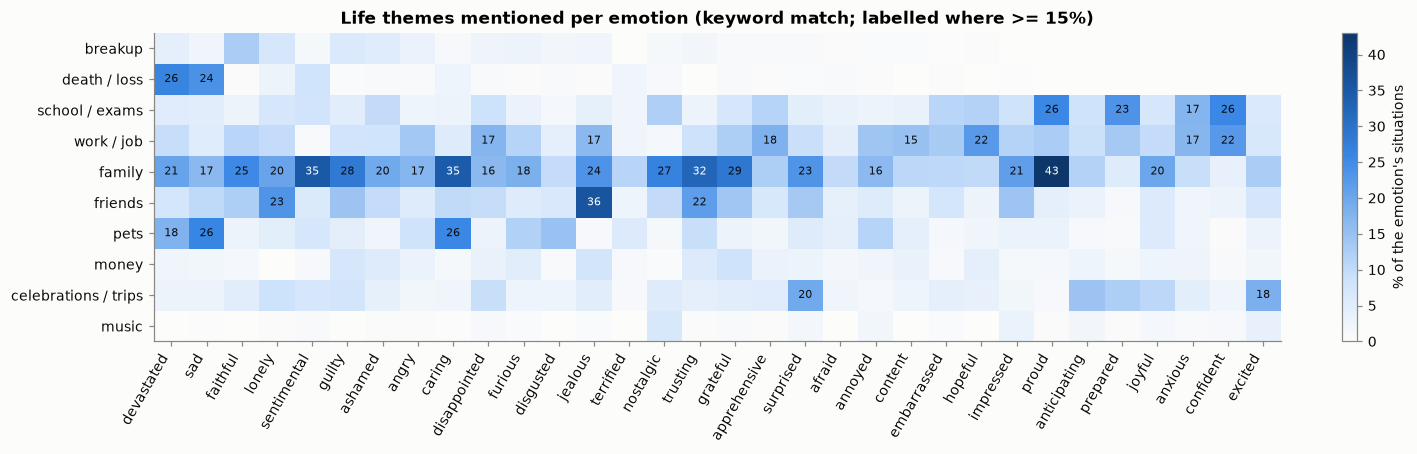

In [27]:
# Emotion x life theme: which situations does each emotion come from?
THEMES = {
    "breakup": r"\b(?:break ?ups?|broke up|dumped|divorc\w*|my ex|cheat\w*)\b",
    "death / loss": r"\b(?:died|dies|dying|death|passed away|funeral)\b",
    "school / exams": r"\b(?:exams?|tests?|school|college|university|grades?|class)\b",
    "work / job": r"\b(?:job|work|boss|promot\w*|fired|hired|interview)\b",
    "family": r"\b(?:mom|dad|mother|father|brother|sister|son|daughter|parents?|kids?|wife|husband)\b",
    "friends": r"\b(?:friends?|buddy)\b",
    "pets": r"\b(?:dogs?|cats?|pets?|puppy|kitten)\b",
    "money": r"\b(?:money|bills?|rent|debt|paycheck|afford)\b",
    "celebrations / trips": r"\b(?:birthday|christmas|vacation|holiday|wedding|party|trip)\b",
    "music": r"\b(?:music|songs?|concert|band)\b",
}
text = ed["situation"].str.lower()
theme_hits = pd.DataFrame({t: text.str.contains(p) for t, p in THEMES.items()})
print("share of all situations mentioning each theme:")
display((theme_hits.mean() * 100).round(1).sort_values(ascending=False).to_frame("%").T)

share = theme_hits.groupby(ed["emotion"]).mean().T * 100
share = share[share.loc[["death / loss", "breakup"]].sum().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(13, 4.2))
im = ax.imshow(share.values, cmap=BLUES, aspect="auto")
ax.set_xticks(range(share.shape[1]), share.columns, rotation=60, ha="right")
ax.set_yticks(range(share.shape[0]), share.index)
ax.grid(False)
for i, j in zip(*np.where(share.values >= 15)):
    ax.text(j, i, f"{share.values[i, j]:.0f}", ha="center", va="center", fontsize=7,
            color="white" if share.values[i, j] > 30 else INK)
fig.colorbar(im, ax=ax, label="% of the emotion's situations", fraction=0.025)
ax.set_title("Life themes mentioned per emotion (keyword match; labelled where >= 15%)")
plt.tight_layout()
plt.show()

In [28]:
# Emotion x vocabulary: the most distinctive words for the music-mood labels
STOP = set("""a about after again all also am an and any are as at be because been before being but by can
could did do does doing don't for from get got had has have having he her him his how i i'm i've if in
into is it it's its just me more my myself no not now of on one or other our out over really she so some
than that the their them then there they this to too up very was we went were what when which while who
will with would you your""".split())


def words(s):
    return [w for w in re.findall(r"[a-z']+", s.lower()) if w not in STOP and len(w) > 2]


per_emotion = {e: Counter(w for s in grp for w in words(s)) for e, grp in ed.groupby("emotion")["situation"]}
overall = sum(per_emotion.values(), Counter())
n_all = sum(overall.values())


def distinctive(e, k=8, min_count=15):
    c, n_e = per_emotion[e], sum(per_emotion[e].values())
    lift = {w: (c[w] / n_e) / (overall[w] / n_all) for w in c if overall[w] >= min_count and c[w] >= 5}
    return ", ".join(sorted(lift, key=lift.get, reverse=True)[:k])


pd.DataFrame({"most distinctive words (lift vs all situations)":
              {e: distinctive(e) for e in sorted(MUSIC_MOODS)}})

,most distinctive words (lift vs all situations)
afraid,"dark, ghost, frightened, terrified, windows, sounds, creepy, gun"
anxious,"stressed, anxious, nervous, dentist, anxiety, what's, nerve, uneasy"
content,"relaxed, shining, relaxing, satisfied, content, relax, peaceful, sun"
devastated,"crushed, heartbroken, destroyed, devastated, distraught, flooded, fire, died"
excited,"pumped, stoked, thrilled, amusement, ecstatic, cruise, smash, bros"
hopeful,"optimistic, fingers, hopeful, crossed, praying, pray, crossing, positive"
joyful,"joyful, happiness, proposed, birth, ecstatic, happy, born, yes"
lonely,"isolated, bored, lonely, alone, empty, quiet, boring, nobody"
nostalgic,"reminded, reminds, album, childhood, memories, pokemon, albums, holidays"
sad,"distraught, cried, depressed, bummed, unhappy, turtle, died, devastated"


**Response.**

**1. Emotion × situation length (box plot).**
- Median length only ranges from 14 words (*excited, proud, sad, joyful*) to 19 (*apprehensive*), and the boxes overlap almost completely.
- So length says almost nothing about the emotion, and a model can't cheat by using length. No correction is needed.

**2. Emotion × life theme (heatmap, keyword matches).** Which kinds of event lead to which emotion:
- **Death/loss** is concentrated in *devastated* (26%) and *sad* (24%). **Pets** are in *sad* and *caring* (26% each). So a "sadness" dimension will mostly learn from grief.
- **School/exams** go with *proud*, *confident* (26%) and *prepared* (23%). **Work/job** goes with *confident* and *hopeful* (22%). These are achievement and stress moods.
- **Family** is the most common theme overall (19% of all situations) and appears under almost every emotion, so it doesn't indicate any one mood.
- **Breakups are rare**: only 428 situations (1.7%), spread over *faithful*, *lonely* and *guilty*. Our motivating example ("I'm going through a breakup") is under-represented, so our own test prompts need to cover it.

**3. Emotion × vocabulary (most distinctive words for the 11 music-mood labels).**
- The words match the labels: *lonely* → isolated, alone, empty, quiet; *nostalgic* → reminded, childhood, memories, album; *anxious* → stressed, nervous, dentist; *devastated* → heartbroken, crushed, died.
- So the text carries the label, and it should be learnable.
- Some labels share words, which makes them candidates for merging into one dimension:
  - *nostalgic* and *sentimental* (photos, albums, "nostalgic")
  - *sad* and *devastated* (distraught, died, devastated), the same feeling at two intensities

**4. Emotion × split (Q8 table).** Every label makes up 1.8–5.3% of each split, so the given splits are stratified and can be used as they are, after the duplicate fix in Q5.

### 8. Provide relevant summary statistics for the features you're planning to use. Briefly explain why you may or may not use certain variables.

In [29]:
display(ed[["split", "emotion"]].describe())
display(ed["n_words"].describe(percentiles=[.1, .5, .9, .99]).round(1).to_frame("situation words").T)
# The given splits are already split by writer: no writer's situations are in two splits
writer_splits = utt[utt["utterance_idx"] == 1].groupby("speaker_idx")["split"].nunique()
print(f"situation writers in more than one split: {(writer_splits > 1).sum()} of {len(writer_splits)}")
# Label balance is the same in every split
ed.groupby("split")["emotion"].value_counts(normalize=True).unstack(0).mul(100).describe().loc[["min", "max"]].round(2)

,split,emotion
count,24850,24850
unique,3,32
top,train,surprised
freq,19533,1279


,count,mean,std,min,10%,50%,90%,99%,max
situation words,24850.0,18.4,10.5,1.0,8.0,16.0,32.0,54.0,136.0


situation writers in more than one split: 0 of 810


split,test,train,valid
min,1.96,1.93,1.84
max,4.99,5.14,5.34


**Response.**

The summary tables above give the label counts, the length percentiles and the label share per split.

| Decision | Feature | Why |
|---|---|---|
| **Use** | `situation` | Model input: short, first-person text that looks like a prompt (median 16 words) |
| **Use** | `emotion` | Label, mapped onto our ~10 mood dimensions in Stage 1. Balanced (478–1,279 per label) |
| **Use** | `split` | The given train/valid/test split is stratified by label and already split by writer (no writer appears in two splits). Kept, after moving cross-split duplicates |
| **Use** | `n_words` | To filter placeholder rows and compare with the length of our own test prompts |
| **Maybe** | `first_utterance` | Extra training text, since it usually retells the situation, but sometimes it's just *"Hi how are you doing today"*. Only with a filter |
| **Drop** | `speaker_idx` | We would use it to split by writer, but the given splits already are |
| **Drop** | `utterance_idx`, `utterance` (later turns), `selfeval`, `tags` | They describe the dialogue, not the situation. The listener's replies aren't prompts, and the ratings and flags say nothing about the emotion |

## Dataset for Song Encoding: MuSe

### 1. Summarise the background of the dataset(s) which you're using, and how they contribute to your project [limited to 100 words per dataset]

**Response.**

MuSe ([Akiki & Burghardt, CHR 2020](http://ceur-ws.org/Vol-2723/short26.pdf); CC BY 4.0) lists 90,001 songs. The authors found them on Last.fm by searching 276 mood words from AllMusic's mood list (the "seeds"). Each song's emotion tags were scored with the Warriner word lexicon to give valence, arousal and dominance, so these are word scores, not ratings of the music. There is no full tag list. We use MuSe as the song catalogue, use the seeds as weak mood labels for the Song Encoder (its input tags come from the Last.fm API, with the seed hidden), and use the 276 seeds as starting vocabulary for the mood dimensions.

#### Loading the data

One CSV, one row per song. `seeds` is stored as a string that looks like a Python list (`"['aggressive', 'angry']"`), so we parse it, count the seeds per song, and make a long table with one row per (song, seed) pair.

In [12]:
muse_path = DATA / "muse" / "muse_v3.csv"
muse = pd.read_csv(muse_path)
muse["seeds"] = muse["seeds"].apply(ast.literal_eval)
muse["n_seeds"] = muse["seeds"].str.len()
VAD = ["valence_tags", "arousal_tags", "dominance_tags"]

seeds_long = muse.explode("seeds").rename(columns={"seeds": "seed"})
seed_counts = seeds_long["seed"].value_counts()
muse.head()

,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre,n_seeds
0,https://www.last.fm/music/eminem/_/%2527till%2bi%2bcollapse,'Till I Collapse,Eminem,[aggressive],6,4.550000,5.273125,5.690625,cab93def-26c5-4fb0-bedd-26ec4c1619e1,4xkOaSrkexMciUUogZKVTS,rap,1
1,https://www.last.fm/music/metallica/_/st.%2banger,St. Anger,Metallica,[aggressive],8,3.710000,5.833000,5.427250,727a2529-7ee8-4860-aef6-7959884895cb,3fOc9x06lKJBhz435mInlH,metal,1
2,https://www.last.fm/music/rick%2bross/_/speedin%2527,Speedin',Rick Ross,[aggressive],1,3.080000,5.870000,5.490000,NaN,3Y96xd4Ce0J47dcalLrEC8,rap,1
3,https://www.last.fm/music/m.i.a./_/bamboo%2bbanga,Bamboo Banga,M.I.A.,"[aggressive, fun, sexy, energetic]",13,6.555071,5.537214,5.691357,99dd2c8c-e7c1-413e-8ea4-4497a00ffa18,6tqFC1DIOphJkCwrjVzPmg,hip-hop,4
4,https://www.last.fm/music/dope/_/die%2bmf%2bdie,Die MF Die,Dope,[aggressive],7,3.771176,5.348235,5.441765,b9eb3484-5e0e-4690-ab5a-ca91937032a5,5bU4KX47KqtDKKaLM4QCzh,metal,1


### 2. State the size of your dataset(s)

In [13]:
print(f"file: {muse_path.stat().st_size / 1e6:.1f} MB; table: {muse.shape[0]:,} rows x {muse.shape[1] - 1} columns")
pd.Series({
    "songs (Last.fm URLs)": muse["lastfm_url"].nunique(),
    "artists": muse["artist"].nunique(),
    "distinct track titles": muse["track"].nunique(),
    "distinct seeds": len(seed_counts),
    "(song, seed) pairs": len(seeds_long),
    "distinct genres": muse["genre"].nunique(),
    "songs with a Spotify ID": muse["spotify_id"].notna().sum(),
    "songs with a MusicBrainz ID": muse["mbid"].notna().sum(),
}).to_frame("count")

file: 18.2 MB; table: 90,001 rows x 11 columns


,count
songs (Last.fm URLs),90001
artists,26012
distinct track titles,79392
distinct seeds,276
"(song, seed) pairs",125154
distinct genres,811
songs with a Spotify ID,61630
songs with a MusicBrainz ID,61217


**Response.**

- **1 CSV, 18.2 MB, 90,001 rows × 11 columns.** We add one derived column, `n_seeds`.
- **90,001 songs** (every Last.fm URL is unique), **26,012 artists**, 79,392 distinct track titles.
- **276 distinct seeds** and 125,154 (song, seed) pairs. **811 distinct genres.**
- 61,630 songs (68%) have a Spotify ID and 61,217 (68%) a MusicBrainz ID.

### 3. For each feature of your dataset, describe what it represents and its data type (numerical, categorical, unstructured string, etc)

In [14]:
display(muse.dtypes.rename("dtype").to_frame().T)
muse[VAD + ["number_of_emotion_tags", "n_seeds"]].agg(["min", "max"]).round(2)

,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre,n_seeds
dtype,str,str,str,object,int64,float64,float64,float64,str,str,str,int64


,valence_tags,arousal_tags,dominance_tags,number_of_emotion_tags,n_seeds
min,0.24,0.11,0.23,1,1
max,8.48,7.27,7.44,50,44


**Response.**

| Feature | What it represents | Data type |
|---|---|---|
| `lastfm_url` | Last.fm page of the song. Unique key | string (ID) |
| `track` | song title | unstructured string |
| `artist` | artist name | categorical, 26,012 levels |
| **`seeds`** | the AllMusic mood word(s) the authors searched to find the song. **Our weak label** | categorical, multi-label (list drawn from 276 words), stored as a string |
| `number_of_emotion_tags` | how many of the song's Last.fm tags were found in the emotion lexicon | numerical, integer (1–50) |
| `valence_tags` | how pleasant the song's emotion tags are, per the Warriner lexicon (nominal scale 1–9) | numerical, continuous |
| `arousal_tags` | how energetic or exciting those tags are (same lexicon) | numerical, continuous |
| `dominance_tags` | how much control or power those tags express (same lexicon) | numerical, continuous |
| `mbid` | MusicBrainz recording ID | string (ID) |
| `spotify_id` | Spotify track ID | string (ID) |
| `genre` | one genre label per song | categorical, 811 levels |
| `n_seeds` (derived) | number of seeds the song was found by | numerical, integer (1–44) |

### 4. For each feature, determine percentage of missing data. Describe how you're planning on resolving the missing data. State any assumptions you make

In [23]:
missing = (muse.drop(columns="n_seeds").isna().mean() * 100).round(2).to_frame("% missing")
display(missing.T)

# Is genre missing at random? Compare with how many emotion tags the song has.
display(muse.groupby(muse["genre"].isna())["number_of_emotion_tags"].describe()[["count", "50%", "mean"]]
        .rename(index={False: "genre present", True: "genre missing"}).round(2))
print("missing both Spotify ID and genre:", (muse["spotify_id"].isna() & muse["genre"].isna()).sum())

NameError: name 'muse' is not defined

**Response.**

| Feature | % missing | Plan |
|---|---|---|
| `mbid` | 31.98% | Leave as missing. It is an ID, not a model input, and we match on Spotify ID or artist + title instead |
| `spotify_id` | 31.52% | Leave as missing. It is only needed for the valence × energy baseline (ReccoBeats) and for playback. Songs without one are left out of the baseline comparison, or matched by artist + title with the hand-checked matching rules |
| `genre` | 7.38% | Fill with `"unknown"`. Genre is only used to describe the catalogue's bias, never as a model input |
| all other columns | 0% | — |

- **Genre is not missing at random.** Songs without a genre have far fewer emotion tags (median 1 vs 3), so they are the less-tagged, less popular songs. We expect these same songs to come back with few tags from the Last.fm API.
- **Assumption:** a missing Spotify ID means MuSe couldn't match the song, not that the song isn't on Spotify.
- **The biggest gap isn't a column: MuSe has no full tag list.** The Song Encoder's input has to be fetched from the Last.fm API (`track.getTopTags`) in Stage 2. Songs whose tags can't be fetched are left out of the v1 catalogue.

### 5. For each feature, identify outliers or mismatched data. Describe how you plan to handle them. Clearly state any assumption you made.

In [22]:
# 1) Duplicate songs
norm = muse.assign(a=muse["artist"].str.lower().str.strip(), t=muse["track"].str.lower().str.strip())
print("duplicate (artist, track), case-insensitive:", norm.duplicated(["a", "t"]).sum())
dup_sp = muse[muse["spotify_id"].notna() & muse["spotify_id"].duplicated(keep=False)]
print(f"rows sharing a Spotify ID with another row: {len(dup_sp)} ({dup_sp['spotify_id'].nunique()} IDs)")
display(dup_sp.sort_values("spotify_id")[["artist", "track", "spotify_id", "seeds"]].head(6))

# 2) Valence/arousal/dominance outside the lexicon's 1-9 scale
out = muse[(muse[VAD] < 1).any(axis=1) | (muse[VAD] > 9).any(axis=1)]
print(f"songs with a V/A/D score outside 1-9: {len(out)}")

# 3) Many songs share exactly the same V/A/D point
shared = muse.duplicated(VAD, keep=False)
print(f"songs sharing their exact V/A/D point with another song: {shared.sum():,} ({shared.mean():.0%}); "
      f"distinct points: {muse[VAD].drop_duplicates().shape[0]:,}")
print("  ...among songs with 1 emotion tag:", f"{shared[muse['number_of_emotion_tags'] == 1].mean():.1%}",
      "| with 5+ tags:", f"{shared[muse['number_of_emotion_tags'] >= 5].mean():.1%}")

# 4) Seed imbalance and artist concentration
print(f"songs per seed: max {seed_counts.max()}, median {seed_counts.median():.0f}, min {seed_counts.min()}; "
      f"seeds with >= 900 songs: {(seed_counts >= 900).sum()}, with < 100 songs: {(seed_counts < 100).sum()}")
print("rarest seeds:", seed_counts.tail(6).to_dict())
print("artists with the most songs:", muse["artist"].value_counts().head(5).to_dict())
print("songs with an extreme number of seeds (>= 20):", (muse["n_seeds"] >= 20).sum())

NameError: name 'muse' is not defined

**Response.**

**1. Duplicate songs.**
- No (artist, track) pair repeats, even ignoring case.
- But **1,863 rows share a Spotify ID with another row** (889 IDs). These are the same song with a punctuation difference (*"Truly, Madly, Deeply"* vs *"Truly Madly Deeply"*), often with different seeds.
- *Plan:* merge rows with the same Spotify ID and combine their seeds.
- *Assumption:* the same Spotify ID means the same recording.

**2. Valence/arousal/dominance outside the 1–9 scale.**
- 332 songs score below 1 (minimum 0.11), which a plain average of Warriner ratings can't produce. So MuSe's formula weights the tags somehow, and the scores are only relative.
- *Plan:* keep them but flag them. We don't use these scores as labels anyway.

**3. Many songs share the same valence/arousal/dominance point.**
- **43,468 songs (48%)** share their exact point with another song, and there are only 50,582 distinct points.
- **99.8% of songs with a single emotion tag** share a point, compared with 6.5% of songs with 5+ tags. A one-tag song's score is just that one word's rating, so it's a copy, not a measurement.
- This confirms the authors' warning, and is another reason not to use these scores as labels.

**4. Seed imbalance.**
- The authors capped each seed at 1,000 songs, but most seeds don't reach the cap: median **290**, 82 seeds at ≥ 900, **91 seeds under 100**. *Opulent*, *virile* and *hymn-like* have 1 song each.
- *Plan:* seeds are grouped into dimensions in Stage 1, so rare seeds join a group. A dimension needs enough songs in total (a coverage check in Stage 1).

**5. Songs with very many seeds.** 72 songs have ≥ 20 seeds (maximum 44). A song found by every word says little about any one mood.
- *Plan:* cap or down-weight these in training.

**6. Artist concentration.** 志方あきこ (302 songs), Skerror (284) and Robbie Williams (207) dominate.
- *Plan:* split train and test by artist, so the model can't learn "artist → mood" instead of "tags → mood".

**7. Seeds that aren't moods.** Many seeds describe sound or style rather than mood (*crunchy, literate, slick, technical, circular*).
- *Plan:* filter them out when fixing the dimensions (Stage 1).

### 6. For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

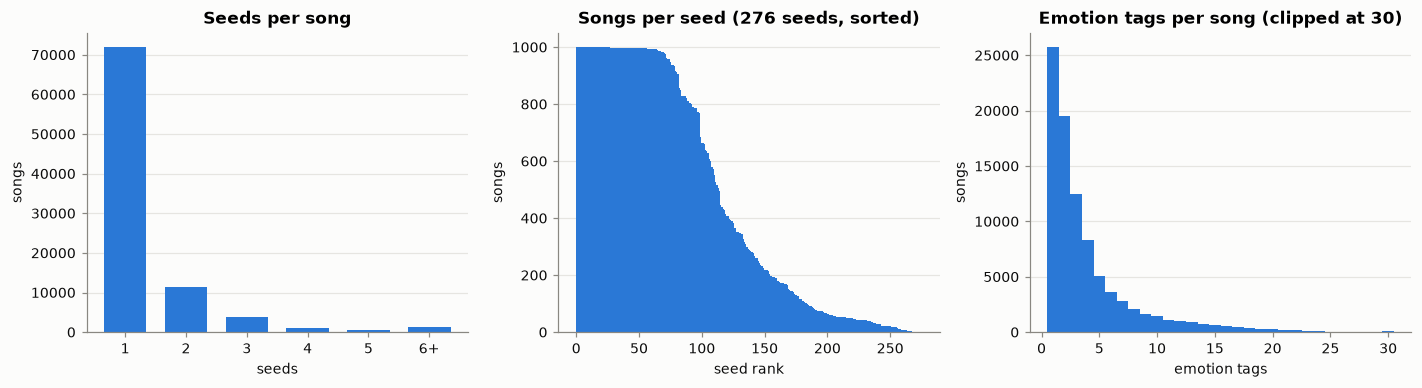

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

per_song = muse["n_seeds"].clip(upper=6).value_counts().sort_index()
axes[0].bar([str(i) if i < 6 else "6+" for i in per_song.index], per_song.values, color=BLUE, width=0.7)
axes[0].set_title("Seeds per song")
axes[0].set_xlabel("seeds")
axes[0].set_ylabel("songs")
axes[0].grid(axis="x", visible=False)

axes[1].bar(range(len(seed_counts)), seed_counts.values, color=BLUE, width=1.0)
axes[1].set_title(f"Songs per seed ({len(seed_counts)} seeds, sorted)")
axes[1].set_xlabel("seed rank")
axes[1].set_ylabel("songs")
axes[1].grid(axis="x", visible=False)

axes[2].hist(muse["number_of_emotion_tags"].clip(upper=30), bins=np.arange(0.5, 31.5), color=BLUE)
axes[2].set_title("Emotion tags per song (clipped at 30)")
axes[2].set_xlabel("emotion tags")
axes[2].set_ylabel("songs")
axes[2].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

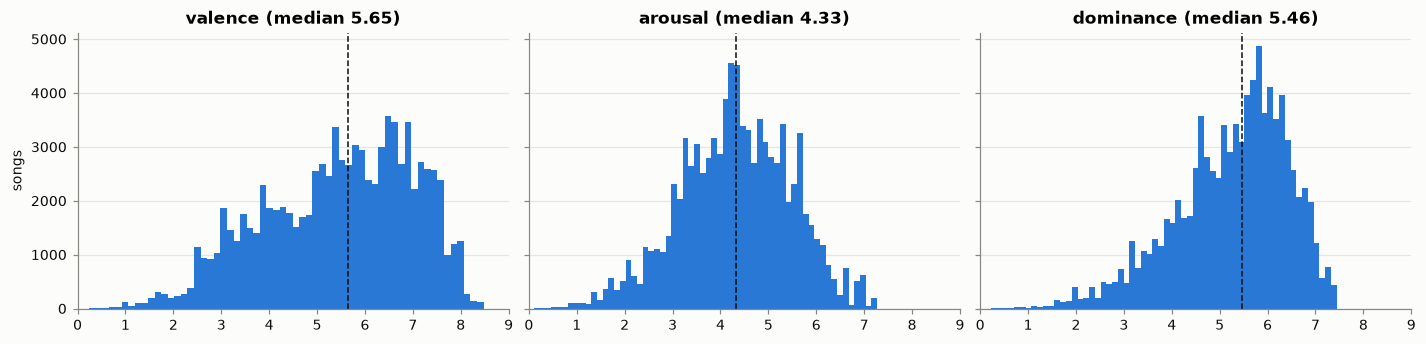

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, col in zip(axes, VAD):
    ax.hist(muse[col], bins=60, color=BLUE)
    ax.axvline(muse[col].median(), color=INK, lw=1, ls="--")
    ax.set_title(f"{col.split('_')[0]} (median {muse[col].median():.2f})")
    ax.set_xlim(0, 9)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("songs")
plt.tight_layout()
plt.show()

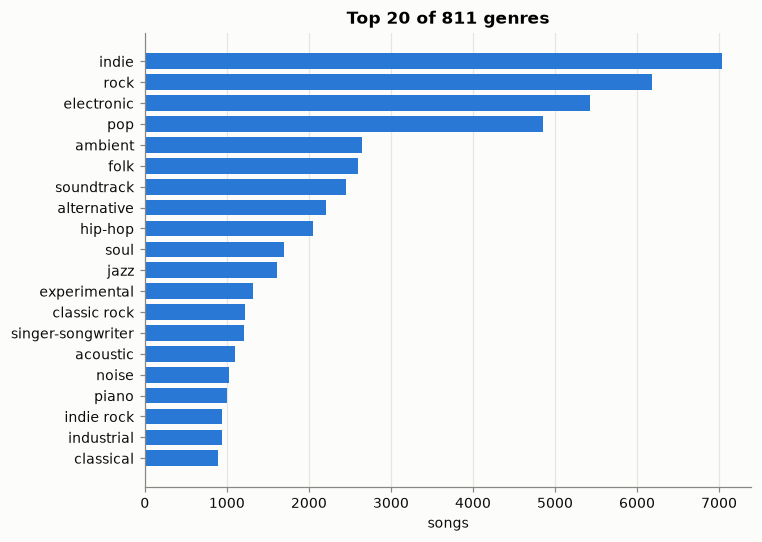

top 20 genres cover 58% of songs with a genre; genres with < 10 songs: 492


In [19]:
top_genres = muse["genre"].value_counts().head(20).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_genres.index, top_genres.values, color=BLUE, height=0.75)
ax.set_title(f"Top 20 of {muse['genre'].nunique()} genres")
ax.set_xlabel("songs")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()
print(f"top 20 genres cover {top_genres.sum() / muse['genre'].notna().sum():.0%} of songs with a genre; "
      f"genres with < 10 songs: {(muse['genre'].value_counts() < 10).sum()}")

**Response.**

**Seeds per song.** 80% of songs (71,934) were found by a single seed and 12.7% by two. Most songs therefore have one weak label, which fits the "this dimension is high" training setup.

**Songs per seed.**
- 66 seeds are at or near the 1,000-song cap (≥ 990 songs), then the counts fall off in a long tail.
- How balanced our dimensions are will depend on which seeds we group together, not on the raw seeds.

**Emotion tags per song.**
- Median 2. 29% of songs have only one emotion tag, and 90% have 9 or fewer.
- Most songs are thinly described *within the lexicon*. Their full Last.fm tag lists will be longer, since those include non-emotion tags.

**Valence / arousal / dominance.**
- Valence has the widest spread (median 5.65, sd 1.55) and leans positive.
- Arousal sits below the scale midpoint (median 4.33). This doesn't mean the catalogue is calm: the lexicon's own words average about 4.2 on arousal (Warriner et al., 2013), so low scores are largely a property of the lexicon.
- Dominance (median 5.46) has almost the same shape as valence.
- The spikes in all three come from the shared points described in Q5.

**Genre.**
- 811 values, but the top 20 cover 58% of songs that have a genre, and 492 genres have fewer than 10 songs.
- Indie (7,041), rock (6,179), electronic (5,432) and pop (4,854) dominate, which reflects Last.fm's mostly Western, indie-leaning userbase.
- We report this as a limitation and check the model on chart pop (PMEmo).

### 7. Perform bi-variate analysis on some of the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables.

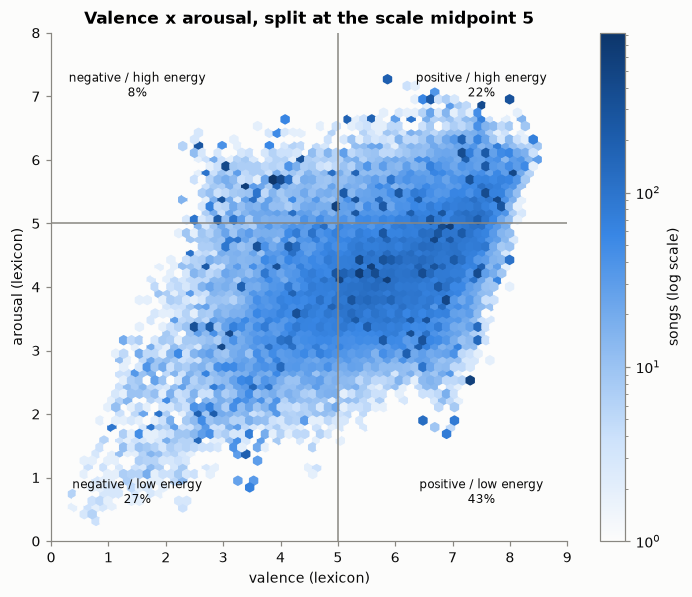

In [20]:
# Valence x arousal: where do the songs sit?
fig, ax = plt.subplots(figsize=(6.5, 5.5))
hb = ax.hexbin(muse["valence_tags"], muse["arousal_tags"], gridsize=60, cmap=BLUES, mincnt=1, bins="log")
ax.axvline(5, color=MUTED, lw=1)
ax.axhline(5, color=MUTED, lw=1)
quad = (np.where(muse["valence_tags"] >= 5, "positive", "negative") + " / "
        + np.where(muse["arousal_tags"] >= 5, "high energy", "low energy"))
qc = pd.Series(quad).value_counts(normalize=True)
for (x, y), name in {(7.5, 7.0): "positive / high energy", (1.5, 7.0): "negative / high energy",
                     (7.5, 0.6): "positive / low energy", (1.5, 0.6): "negative / low energy"}.items():
    ax.text(x, y, f"{name}\n{qc[name]:.0%}", ha="center", color=INK, fontsize=8)
ax.set_xlim(0, 9)
ax.set_ylim(0, 8)
ax.set_xlabel("valence (lexicon)")
ax.set_ylabel("arousal (lexicon)")
ax.set_title("Valence x arousal, split at the scale midpoint 5")
ax.grid(False)
fig.colorbar(hb, ax=ax, label="songs (log scale)")
plt.tight_layout()
plt.show()

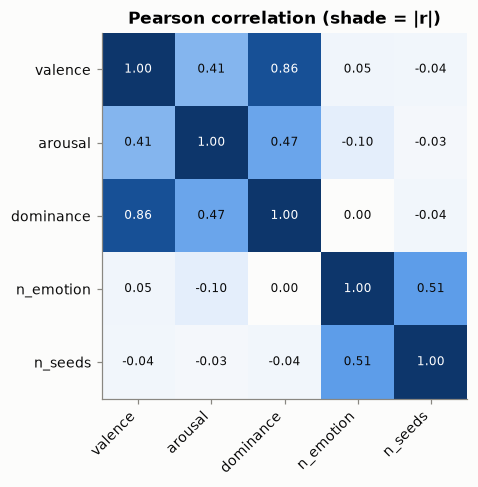

In [21]:
# Correlations between the numeric features
corr = muse[VAD + ["number_of_emotion_tags", "n_seeds"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(corr.abs(), cmap=BLUES, vmin=0, vmax=1)
labels = [c.replace("_tags", "").replace("number_of_emotion", "n_emotion") for c in corr.columns]
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else INK)
ax.set_title("Pearson correlation (shade = |r|)")
plt.tight_layout()
plt.show()

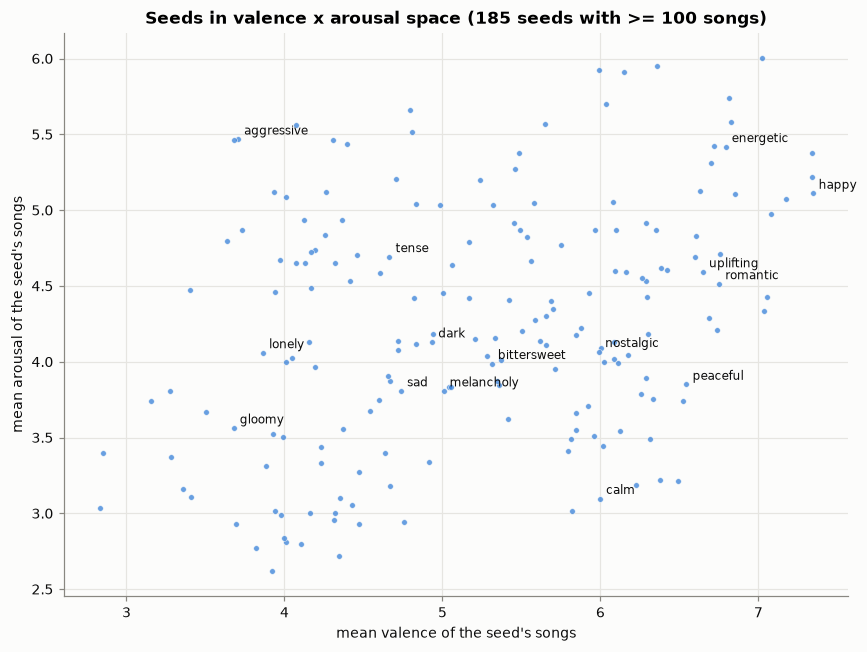

lowest valence: {'macabre': 2.83, 'sardonic': 2.85, 'cynical': 3.15, 'sarcastic': 3.27, 'fractured': 3.28}
highest valence: {'happy': 7.34, 'cheerful': 7.34, 'fun': 7.34, 'humorous': 7.17, 'positive': 7.08}
highest arousal: {'exciting': 6.0, 'sexual': 5.95, 'erotic': 5.92, 'spicy': 5.91, 'exotic': 5.74}


In [22]:
# Seed x valence/arousal: does each seed word sit where its meaning says it should?
by_seed = seeds_long.groupby("seed").agg(valence=("valence_tags", "mean"), arousal=("arousal_tags", "mean"),
                                         songs=("seed", "size"))
by_seed = by_seed[by_seed["songs"] >= 100]
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(by_seed["valence"], by_seed["arousal"], s=14, color=BLUE, alpha=0.7, edgecolor="#fcfcfb", lw=0.5)
for s in ["happy", "sad", "gloomy", "lonely", "nostalgic", "aggressive", "calm", "peaceful",
          "romantic", "energetic", "melancholy", "dark", "uplifting", "tense", "bittersweet"]:
    if s in by_seed.index:
        ax.annotate(s, by_seed.loc[s, ["valence", "arousal"]], xytext=(4, 3), textcoords="offset points",
                    fontsize=8, color=INK)
ax.set_xlabel("mean valence of the seed's songs")
ax.set_ylabel("mean arousal of the seed's songs")
ax.set_title(f"Seeds in valence x arousal space ({len(by_seed)} seeds with >= 100 songs)")
plt.tight_layout()
plt.show()
print("lowest valence:", by_seed["valence"].nsmallest(5).round(2).to_dict())
print("highest valence:", by_seed["valence"].nlargest(5).round(2).to_dict())
print("highest arousal:", by_seed["arousal"].nlargest(5).round(2).to_dict())

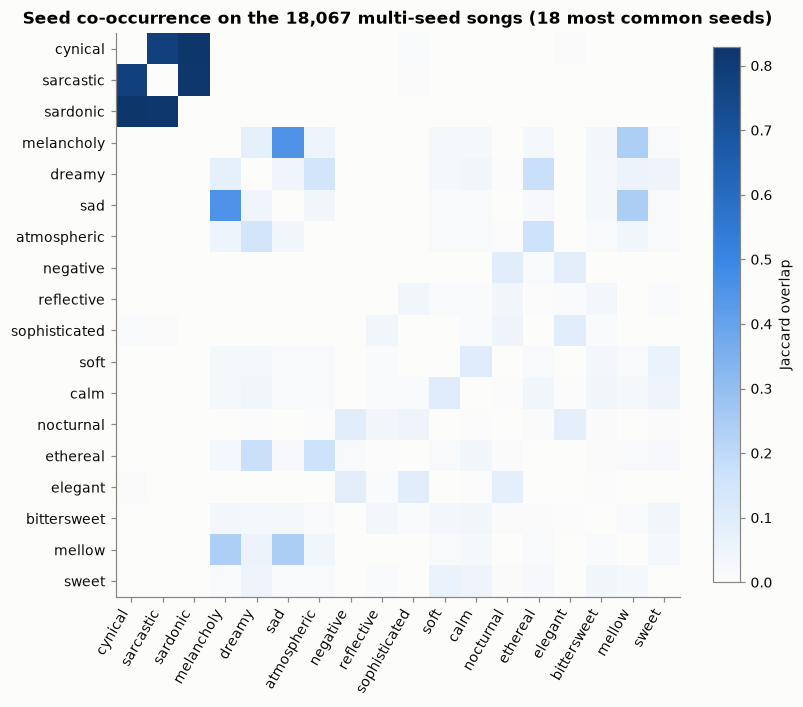

strongest pairs: {'cynical + sardonic': 0.83, 'sarcastic + sardonic': 0.82, 'cynical + sarcastic': 0.78, 'sad + melancholy': 0.45, 'mellow + sad': 0.24, 'melancholy + mellow': 0.24, 'ethereal + dreamy': 0.17, 'atmospheric + ethereal': 0.16}


In [23]:
# Seed x seed: which seeds are found on the same songs?
multi = muse[muse["n_seeds"] > 1]
top = multi.explode("seeds")["seeds"].value_counts().head(18).index
onehot = pd.DataFrame({s: multi["seeds"].apply(lambda xs, s=s: s in xs) for s in top}).astype(int)
co = onehot.T @ onehot
jaccard = co / (np.add.outer(np.diag(co), np.diag(co)) - co)
jaccard = jaccard.mask(np.eye(len(top), dtype=bool))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(jaccard, cmap=BLUES)
ax.set_xticks(range(len(top)), top, rotation=60, ha="right")
ax.set_yticks(range(len(top)), top)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Jaccard overlap", fraction=0.04)
ax.set_title(f"Seed co-occurrence on the {len(multi):,} multi-seed songs (18 most common seeds)")
plt.tight_layout()
plt.show()
pairs = jaccard.where(np.triu(np.ones(jaccard.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
print("strongest pairs:", {f"{a} + {b}": round(v, 2) for (a, b), v in pairs.head(8).items()})

**Response.**

**1. Valence × arousal (hexbin, split at the midpoint 5).**
- 43% of songs are positive / low energy and 27% negative / low energy. Only 22% are positive / high energy and **8% negative / high energy**.
- Valence and arousal are moderately correlated (r = 0.41): the lexicon's pleasant words also tend to be its energetic words.
- The negative / high-energy quadrant is the smallest because few seeds describe tense or aggressive music. The seeds that do (*aggressive*, *angry*) sit in that quadrant (see the seed plot below).

**2. Correlations between numeric features.**
- **Valence and dominance: r = 0.86.** Dominance adds almost nothing beyond valence.
- `number_of_emotion_tags` and `n_seeds`: r = 0.51. Well-tagged songs were found by more seeds.
- How many tags a song has barely relates to its scores (|r| ≤ 0.10), so tagging amount doesn't bias the score direction.

**3. Seed × valence/arousal (one dot per seed with ≥ 100 songs).**
- The seeds sit where their meaning says they should:
  - *happy, cheerful, fun* have the highest valence (≈ 7.3)
  - *macabre, sardonic, cynical* have the lowest
  - *aggressive* and *angry* are high arousal, low valence
  - *calm* and *peaceful* are low arousal, positive valence
  - *lonely* and *gloomy* sit at low valence and lower arousal. *sad* and *melancholy* sit nearer the middle, close to *bittersweet*, and *nostalgic* is mildly positive
- **This is partly circular.** Each seed is itself one of the song's tags, so it feeds into the song's score. For the 29% of songs with a single emotion tag, the score is just the seed word's own lexicon rating. The plot shows that the seeds and the lexicon agree (a sanity check), not that the seeds describe the music. The human check on PMEmo (Stage 4) is what tests that.
- Neighbouring seeds still suggest natural groups.

**4. Seed × seed co-occurrence (Jaccard overlap on the 18,067 multi-seed songs).**
- *cynical / sarcastic / sardonic* overlap 0.78–0.83, so they find almost the same songs and form one group.
- *sad + melancholy* overlap 0.45. *mellow* overlaps 0.24 with both, and *ethereal / dreamy / atmospheric* overlap about 0.16.
- Single-seed songs are left out, so these overlaps are higher than they would be across all songs. Read them as relative, not absolute.
- These overlaps come from the data, and they back up the synonym groups we draw up by hand in Stage 1. Most other pairs barely overlap, so most seeds are distinct.

### 8. Provide relevant summary statistics for the features you're planning to use. Briefly explain why you may or may not use certain variables.

In [24]:
display(muse[VAD + ["number_of_emotion_tags", "n_seeds"]].describe(percentiles=[.25, .5, .75, .99]).round(2))
display(seed_counts.describe().round(1).to_frame("songs per seed").T)
muse[["artist", "genre"]].describe()

,valence_tags,arousal_tags,dominance_tags,number_of_emotion_tags,n_seeds
count,90001.00,90001.00,90001.00,90001.00,90001.00
mean,5.45,4.32,5.25,3.99,1.39
std,1.55,1.15,1.17,4.15,1.36
min,0.24,0.11,0.23,1.00,1.00
25%,4.28,3.53,4.55,1.00,1.00
50%,5.65,4.33,5.46,2.00,1.00
75%,6.70,5.15,6.12,5.00,1.00
99%,8.00,6.90,7.21,20.00,6.00
max,8.48,7.27,7.44,50.00,44.00


,count,mean,std,min,25%,50%,75%,max
songs per seed,276.0,453.5,406.9,1.0,54.8,289.5,983.0,1000.0


,artist,genre
count,90001,83362
unique,26012,811
top,志方あきこ,indie
freq,302,7041


**Response.**

The summary tables above give the numeric features, songs per seed, and the artist and genre counts.

| Decision | Feature | Why |
|---|---|---|
| **Use** | `seeds` | Weak label: each seed maps to a mood dimension in Stage 1. The seed and its synonyms are also **removed** from the song's input tags, so the model can't copy the answer |
| **Use** | `artist`, `track` | To fetch each song's Last.fm tags (`track.getTopTags`), the Song Encoder's input. `artist` is also used to split train and test by artist |
| **Use** | `lastfm_url` | Unique key |
| **Use** | `spotify_id` | For de-duplication (Q5), the valence × energy baseline and playback. Not a model input |
| **Use** | `number_of_emotion_tags`, `n_seeds` | To flag thinly-tagged songs and down-weight songs with many seeds |
| **Describe only** | `genre` | To report the catalogue's bias. Not a model input, so the model stays about mood rather than genre |
| **Sanity check only** | `valence_tags`, `arousal_tags` | Word scores of the tags, not ratings of the music. Comparing our tag model against them would be circular. At most a rough check |
| **Drop** | `dominance_tags` | r = 0.86 with valence, so it adds almost nothing |
| **Drop** | `mbid` | A second ID. We match on Spotify ID or artist + title |

## Last.fm tags: sample fetch (1,000 songs)

> **Sample only.** This checks that we *can* fetch each song's tags from the Last.fm API, and that the tags are rich enough to weight and analyse. It is not the full catalogue fetch.

MuSe keeps only the mood word (seed) that found each song, not the song's full tag list. So for a random sample of **1,000 MuSe songs** we call [`track.getTopTags`](https://www.last.fm/api/show/track.getTopTags) with the song's `artist` and `track` (`autocorrect=1` fixes small spelling differences).

Each tag comes with a `count`: a **relative weight from 0 to 100**, where the song's most-used tag is 100.

**Setup:** paste your key into `mood-playlist/.env` as `LASTFM_API_KEY=...` (the file is git-ignored). Every response is cached to `data/raw/lastfm/sample_1000.jsonl`, so re-running the notebook makes no API calls. An interrupted fetch picks up where it stopped.

In [ ]:
import json
import time
import urllib.parse
import urllib.request
from urllib.error import HTTPError, URLError

INTERIM = Path("../data/interim")
LASTFM_CACHE = DATA / "lastfm" / "sample_1000.jsonl"
N_SAMPLE = 1000
MIN_COUNT = 5  # a tag "counts" if its weight is at least 5 (of 100)
MIN_TAGS = 5   # a song is usable if it has at least 5 such tags, seed words excluded

sample = muse.sample(N_SAMPLE, random_state=42)[["lastfm_url", "artist", "track", "seeds"]]


def read_env(path):
    """Minimal .env reader: KEY=value lines, # comments."""
    env = {}
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if "=" in line and not line.lstrip().startswith("#"):
            key, value = line.split("=", 1)
            env[key.strip()] = value.strip().strip("\"'")
    return env


def get_top_tags(artist, track, api_key, retries=5):
    """One track.getTopTags call. Returns the parsed JSON (which may hold a Last.fm error)."""
    query = urllib.parse.urlencode({"method": "track.gettoptags", "artist": artist, "track": track,
                                    "autocorrect": 1, "api_key": api_key, "format": "json"})
    request = urllib.request.Request(f"https://ws.audioscrobbler.com/2.0/?{query}",
                                     headers={"User-Agent": "MoodMix-student-project/0.1"})
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(request, timeout=20) as r:
                data = json.load(r)
        except HTTPError as e:  # Last.fm sends errors as JSON with a 4xx/5xx status
            try:
                data = json.load(e)
            except ValueError:
                data = {"error": e.code, "message": str(e)}
        except (URLError, TimeoutError, ValueError) as e:
            data = {"error": -1, "message": str(e)}
        # 29 = rate limited, 11/16 = service temporarily down, -1/5xx = network: wait and retry
        if data.get("error") in (29, 11, 16, -1) or data.get("error", 0) >= 500:
            time.sleep(2 ** attempt)
            continue
        return data
    return data

In [ ]:
# Fetch every sampled song not already in the cache (~4 requests/second, ~5 minutes for 1,000).
LASTFM_CACHE.parent.mkdir(parents=True, exist_ok=True)
done = set()
if LASTFM_CACHE.exists():
    with LASTFM_CACHE.open(encoding="utf-8") as f:
        done = {json.loads(line)["lastfm_url"] for line in f}

todo = sample[~sample["lastfm_url"].isin(done)]
if len(todo):
    api_key = read_env("../.env").get("LASTFM_API_KEY")
    assert api_key, "Paste your key into mood-playlist/.env as LASTFM_API_KEY=..."
    with LASTFM_CACHE.open("a", encoding="utf-8") as f:
        for i, row in enumerate(todo.itertuples(), 1):
            started = time.monotonic()
            response = get_top_tags(row.artist, row.track, api_key)
            f.write(json.dumps({"lastfm_url": row.lastfm_url, "response": response}) + "\n")
            f.flush()
            if i % 100 == 0:
                print(f"{i}/{len(todo)} fetched")
            time.sleep(max(0, 0.25 - (time.monotonic() - started)))
print(f"cache: {len(done) + len(todo):,} songs ({len(todo):,} fetched now)")

#### Tidy tables

One row per (song, tag) pair in `lastfm_tags_sample.csv`, and one status per song in `lastfm_status_sample.csv`:
- `ok`: the song was found and has at least one tag
- `no_tags`: the song was found but nobody has tagged it
- `not_found`: Last.fm doesn't know the song (error 6)
- `error`: any other API error, after retries

Tag names are lower-cased and trimmed, so *Sad* and *sad* are one tag (we keep the higher weight).

In [ ]:
tag_rows, status_rows = [], []
with LASTFM_CACHE.open(encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        url, resp = rec["lastfm_url"], rec["response"]
        if "error" in resp:
            status = "not_found" if resp["error"] == 6 else "error"
        else:
            tags = resp.get("toptags", {}).get("tag", [])
            tags = [tags] if isinstance(tags, dict) else tags  # a single tag comes back as an object
            tag_rows += [(url, t["name"].strip().lower(), int(t["count"])) for t in tags]
            status = "ok" if tags else "no_tags"
        status_rows.append((url, status))

lfm_tags = (pd.DataFrame(tag_rows, columns=["lastfm_url", "tag", "count"])
            .sort_values("count", ascending=False).drop_duplicates(["lastfm_url", "tag"]))
lfm_status = pd.DataFrame(status_rows, columns=["lastfm_url", "status"]).drop_duplicates("lastfm_url", keep="last")
lfm_tags.to_csv(INTERIM / "lastfm_tags_sample.csv", index=False)
lfm_status.to_csv(INTERIM / "lastfm_status_sample.csv", index=False)
lfm_tags.head()

#### Are the tags usable?

A song is **usable** if, after removing its own seed word(s), it still has at least `MIN_TAGS` = 5 tags with weight `MIN_COUNT` ≥ 5. That is the input the Song Encoder would see.

We also check how often the seed itself appears in the song's tags. A high rate confirms the leakage risk in the proposal: if the seed stays in the input, the model can just copy it.

In [ ]:
seed_vocab = set(seed_counts.index)
lfm = lfm_tags.merge(sample[["lastfm_url", "seeds"]], on="lastfm_url")
lfm["is_seed"] = [t in s for t, s in zip(lfm["tag"], lfm["seeds"])]
strong = lfm[lfm["count"] >= MIN_COUNT]

per_song = sample[["lastfm_url"]].merge(lfm_status, on="lastfm_url", how="left").fillna({"status": "not fetched"})
per_song["tags_all"] = per_song["lastfm_url"].map(lfm.groupby("lastfm_url").size()).fillna(0).astype(int)
per_song["tags_strong_no_seed"] = (per_song["lastfm_url"]
                                   .map(strong[~strong["is_seed"]].groupby("lastfm_url").size()).fillna(0).astype(int))
per_song["seed_in_tags"] = per_song["lastfm_url"].isin(lfm.loc[lfm["is_seed"], "lastfm_url"])
per_song["usable"] = per_song["tags_strong_no_seed"] >= MIN_TAGS

display(per_song["status"].value_counts().to_frame("songs").assign(
    pct=lambda d: (d["songs"] / len(per_song) * 100).round(1)).T)
ok = per_song[per_song["status"] == "ok"]
pd.Series({
    "usable songs (of sample)": f"{per_song['usable'].sum():,} ({per_song['usable'].mean():.1%})",
    "seed word among the song's tags (of found songs)": f"{ok['seed_in_tags'].mean():.1%}",
    "median tags per found song (all weights)": ok["tags_all"].median(),
    f"median tags per found song (weight >= {MIN_COUNT}, seed removed)": ok["tags_strong_no_seed"].median(),
    "distinct tags in sample": f"{lfm['tag'].nunique():,}",
    "share of tags (weight >= 5) that are also MuSe seed words": f"{strong['tag'].isin(seed_vocab).mean():.1%}",
}).to_frame("value")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1, 1.2]})

axes[0].hist(ok["tags_strong_no_seed"].clip(upper=60), bins=np.arange(-0.5, 61.5, 2), color=BLUE)
axes[0].axvline(MIN_TAGS, color=ORANGE, lw=1.5, ls="--", label=f"usable cut-off ({MIN_TAGS})")
axes[0].set_title(f"Tags per found song (weight >= {MIN_COUNT}, seed removed)")
axes[0].set_xlabel("tags (clipped at 60)")
axes[0].set_ylabel("songs")
axes[0].legend()
axes[0].grid(axis="x", visible=False)

axes[1].hist(lfm["count"], bins=np.arange(-0.5, 101.5, 5), color=BLUE)
axes[1].set_title("Tag weights")
axes[1].set_xlabel("count (0-100, top tag = 100)")
axes[1].set_ylabel("tags")
axes[1].set_yscale("log")
axes[1].grid(axis="x", visible=False)

top = strong.groupby("tag")["lastfm_url"].nunique().nlargest(30).sort_values()
axes[2].barh(top.index, top.values, color=[BLUE if t in seed_vocab else GREY for t in top.index])
axes[2].set_title(f"Top 30 tags (songs with weight >= {MIN_COUNT})")
axes[2].set_xlabel("songs")
axes[2].tick_params(axis="y", labelsize=8)
axes[2].legend(handles=[Patch(color=BLUE, label="MuSe mood word"), Patch(color=GREY, label="other")], loc="lower right")
axes[2].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Response.**

`[TODO]` Fill in once the fetch has run.

- **Fetching works?** `[TODO]` % found / not found / no tags.
- **Enough tags to weight?** `[TODO]` % usable, median tags per song after removing the seed.
- **Are the tags meaningful?** `[TODO]` What the top tags are: mood words vs genre vs junk (*seen live*, *favourites*). Which ones to filter.
- **Leakage check.** `[TODO]` % of songs whose seed appears in their own tags.

## Draft mood dimensions (rough)

Rough work. The aim is to see whether we can get a small set of named mood dimensions that make sense, and whether the two datasets can agree on them: a dimension needs prompts from EmpatheticDialogues *and* songs from MuSe.

As a first step, the cell below collects every candidate term from both datasets into one list (`mood_labels.csv`): the MuSe seeds, the EmpatheticDialogues labels, and the most distinctive words per label. Many distinctive words are topics rather than moods (*ghost*, *pokemon*, *turtle*), so the grouping step must be able to drop terms as well as group them.

In [25]:
# One row per distinct term; `source` says which list(s) it came from.
# (The seeds' co-occurring words are themselves seeds, so they are already covered by muse_seed.)
ed_words = {w for e in ed["emotion"].unique() for w in distinctive(e).split(", ") if w}
labels = (pd.concat([
    pd.DataFrame({"label": seed_counts.index, "source": "muse_seed"}),
    pd.DataFrame({"label": ed["emotion"].unique(), "source": "ed_label"}),
    pd.DataFrame({"label": sorted(ed_words), "source": "ed_distinctive_word"}),
]).groupby("label")["source"].agg("; ".join).reset_index())

LABELS_PATH = Path("../data/interim/mood_labels.csv")
LABELS_PATH.parent.mkdir(parents=True, exist_ok=True)
labels.to_csv(LABELS_PATH, index=False)
print(f"saved {len(labels)} labels to {LABELS_PATH}")
labels["source"].value_counts()

saved 502 labels to ..\data\interim\mood_labels.csv


source
muse_seed                                   258
ed_distinctive_word                         201
ed_label; ed_distinctive_word                22
muse_seed; ed_distinctive_word               11
muse_seed; ed_label; ed_distinctive_word      6
ed_label                                      3
muse_seed; ed_label                           1
Name: count, dtype: int64

## TODO

**1. Classify every term into the mood dimensions (LLM).**
- Input: all 502 terms in `mood_labels.csv`: the 276 MuSe seeds, the 32 EmpatheticDialogues labels and the distinctive words.
- Give the LLM the fixed list of ~10 dimensions with their written definitions. It returns one dimension per term, or *drop* for terms that aren't moods (sound/style seeds such as *crunchy*, topic words such as *ghost*).
- Save the mapping to `data/interim/`, record the model and prompt used, and have a person check it.
- Add this mapping to `ed` as a column and re-run ED Q3, Q6 and Q8 so they match.
- **Coverage table:** for each dimension, count the ED situations and the MuSe songs it gets. A dimension with too few of either can't be trained or tested, so merge or drop it.

**2. Last.fm tag sample (once we have an API key).**
- MuSe has no full tag list, so the Song Encoder's input has to be fetched (`track.getTopTags`). Fetch tags for ~300 random MuSe songs and cache them.
- Report: share of songs with any tags, tags per song, how often the seed is among them, and how many mood-related tags are left once the seed and its synonyms are removed.
- Why: 29% of songs have only one emotion tag (Q6), probably the seed itself. If hiding the seed leaves those songs with nothing useful, the Song Encoder has little to learn from.
